<a href="https://colab.research.google.com/github/VadimFilips/ProjectFilipsGit/blob/main/%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5%20%E2%84%962/%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_%E2%84%962.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
#ml_module.py
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


def train_model(X, y):
    """
    Обучение модели линейной регрессии.
    """
    model = LinearRegression()
    model.fit(X, y)
    return model

def predict(model, X):
    """
    Предсказание на новых данных.
    """
    return model.predict(X)

def evaluate_model(y_true, y_pred):
    """
    Оценка модели.
    """
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, r2


In [46]:
#data_processing.py

def preprocess_data(df, target_column):
    """
    Предобработка данных для модели.
    """
    X = df.drop(columns=[target_column])
    y = df[target_column]

    numeric_features = ['Length', 'Diameter', 'Height',
                       'Whole weight', 'Shucked weight',
                       'Viscera weight', 'Shell weight']
    categorical_features = ['Sex']

    numeric_transformer = StandardScaler()
    categorical_transformer = OneHotEncoder(drop='first')

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])

    X_processed = preprocessor.fit_transform(X)

    processed_feature_names = (
        numeric_features +
        preprocessor.named_transformers_['cat']
        .get_feature_names_out(categorical_features)
        .tolist()
    )

    return {
        'X': pd.DataFrame(X_processed, columns=processed_feature_names),
        'y': y,
        'preprocessor': preprocessor
    }

In [47]:
# data_loader.py
def load_csv(file_path):
    """
    Загрузка данных из CSV файла
    """
    try:
        data = pd.read_csv(file_path)
        return data
    except Exception as e:
        print(f"Ошибка загрузки CSV: {e}")
        return None

In [52]:
# missing_values.py
import pandas as pd
import numpy as np

def check_missing_values(df):
    """
    Проверка наличия пропущенных значений в датафрейме
    """
    # Общее количество пропущенных значений
    total_missing = df.isnull().sum().sum()

    # Пропущенные значения по столбцам
    missing_by_column = df.isnull().sum()

    # Процент пропущенных значений
    missing_percentage = (df.isnull().sum() / len(df)) * 100

    return {
        'total_missing': total_missing,
        'missing_by_column': missing_by_column,
        'missing_percentage': missing_percentage
    }

def handle_missing_values(df, strategy='mean'):
    """
    Обработка пропущенных значений
    :param strategy: метод обработки ('mean', 'median', 'mode', 'drop')
    """
    if strategy == 'mean':
        return df.fillna(df.mean())
    elif strategy == 'median':
        return df.fillna(df.median())
    elif strategy == 'mode':
        return df.fillna(df.mode().iloc[0])
    elif strategy == 'drop':
        return df.dropna()
    else:
        raise ValueError("Неподдерживаемая стратегия обработки пропусков")

# Удалена функция визуализации
# def visualize_missing_values(df):
#     ...

def get_missing_summary(df):
    """
    Получение сводной информации о пропущенных значениях
    """
    missing_info = check_missing_values(df)
    summary = pd.DataFrame({
        'missing_count': missing_info['missing_by_column'],
        'missing_percentage': missing_info['missing_percentage']
    })
    return summary


In [85]:
# visualization.py

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

class DataVisualizer:
    def __init__(self, data):
        self.original_data = data.copy()  # Сохраняем оригинальные данные
        self.data = self._preprocess_data(data)

    def _preprocess_data(self, data):
        # Кодируем категориальную переменную Sex
        encoder = OneHotEncoder(drop='first', sparse_output=False)
        sex_encoded = encoder.fit_transform(data[['Sex']])

        # Преобразуем в DataFrame
        sex_df = pd.DataFrame(sex_encoded,
                             columns=encoder.get_feature_names_out(['Sex']),
                             index=data.index)

        # Объединяем с исходными данными
        return pd.concat([data.drop('Sex', axis=1), sex_df], axis=1)

    def plot_histogram(self, column):
        plt.figure(figsize=(10, 6))
        sns.histplot(self.data[column], kde=True)
        plt.title(f'Гистограмма {column}')
        plt.xlabel(column)
        plt.ylabel('Частота')
        plt.show()

    def plot_scatter(self, x_column, y_column, hue=None):
        # Используем оригинальные данные для визуализации с Sex
        plt.figure(figsize=(12, 8))
        sns.scatterplot(
            data=self.original_data,
            x=x_column,
            y=y_column,
            hue='Sex'  # Используем оригинальный столбец Sex
        )
        plt.title(f'Диаграмма рассеяния {y_column} от {x_column}')
        plt.xlabel(x_column)
        plt.ylabel(y_column)
        plt.legend()
        plt.show()

    def plot_line_chart(self, x_column, y_column):
        plt.figure(figsize=(12, 8))

        # Сортируем данные
        sorted_data = self.data.sort_values(by=[x_column])

        # Строим график
        plt.plot(
            sorted_data[x_column],
            sorted_data[y_column],
            marker='o',
            linestyle='-',
            color='blue',
            alpha=0.7
        )
        # Добавляем линию тренда
        z = np.polyfit(sorted_data[x_column], sorted_data[y_column], 1)
        p = np.poly1d(z)
        plt.plot(
            sorted_data[x_column],
            p(sorted_data[x_column]),
            "r--",
            label=f'Тренд: y={z[0]:.2f}x+{z[1]:.2f}'
        )

        # Упрощенные подписи
        plt.title('Зависимость веса от количества колец')
        plt.xlabel('Количество колец')
        plt.ylabel('Общий вес (г)')

        # Настройка оси X только с числами
        plt.xticks(
            ticks=sorted_data[x_column].unique(),
            rotation=45
        )

        # Базовая настройка графика
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_correlation_matrix(self):
        plt.figure(figsize=(12, 10))
        corr = self.data.corr()
        sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
        plt.title('Матрица корреляции')
        plt.show()

    def plot_boxplot(self, column, hue=None):
        # Используем оригинальные данные для визуализации с Sex
        plt.figure(figsize=(10, 6))
        sns.boxplot(
            data=self.original_data,
            x=column,
            hue='Sex'  # Используем оригинальный столбец Sex
        )
        plt.title(f'Боксплот {column}')
        plt.show()

Общее количество пропусков: 0
Пропуски по столбцам:
 Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked weight    0
Viscera weight    0
Shell weight      0
Rings             0
dtype: int64

Сводная информация о пропусках:
                 missing_count  missing_percentage
Sex                         0                 0.0
Length                      0                 0.0
Diameter                    0                 0.0
Height                      0                 0.0
Whole weight                0                 0.0
Shucked weight              0                 0.0
Viscera weight              0                 0.0
Shell weight                0                 0.0
Rings                       0                 0.0
Среднеквадратичная ошибка: 4.78
Коэффициент детерминации R^2: 0.53


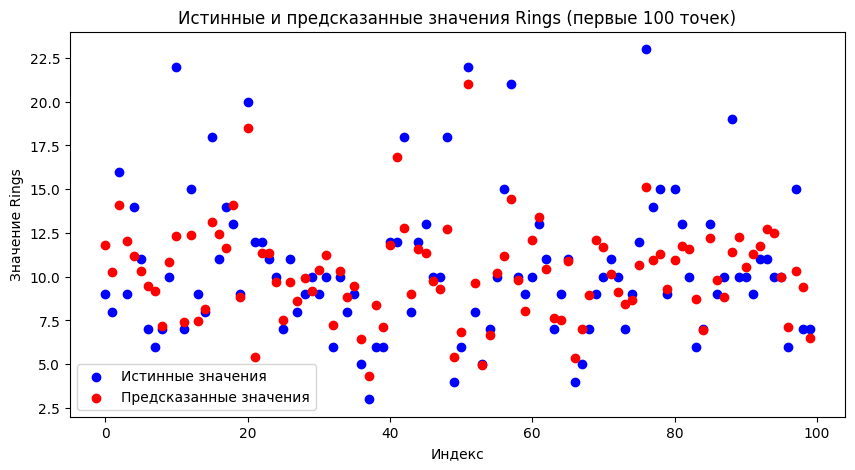

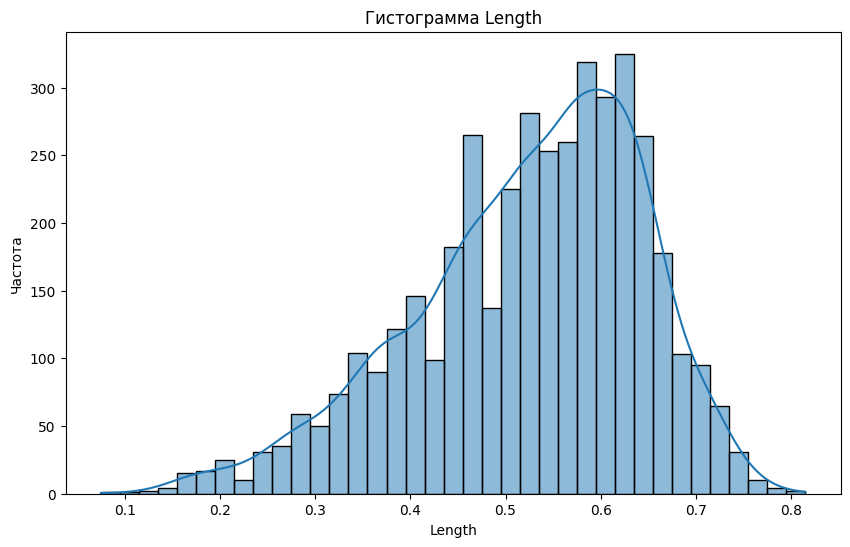

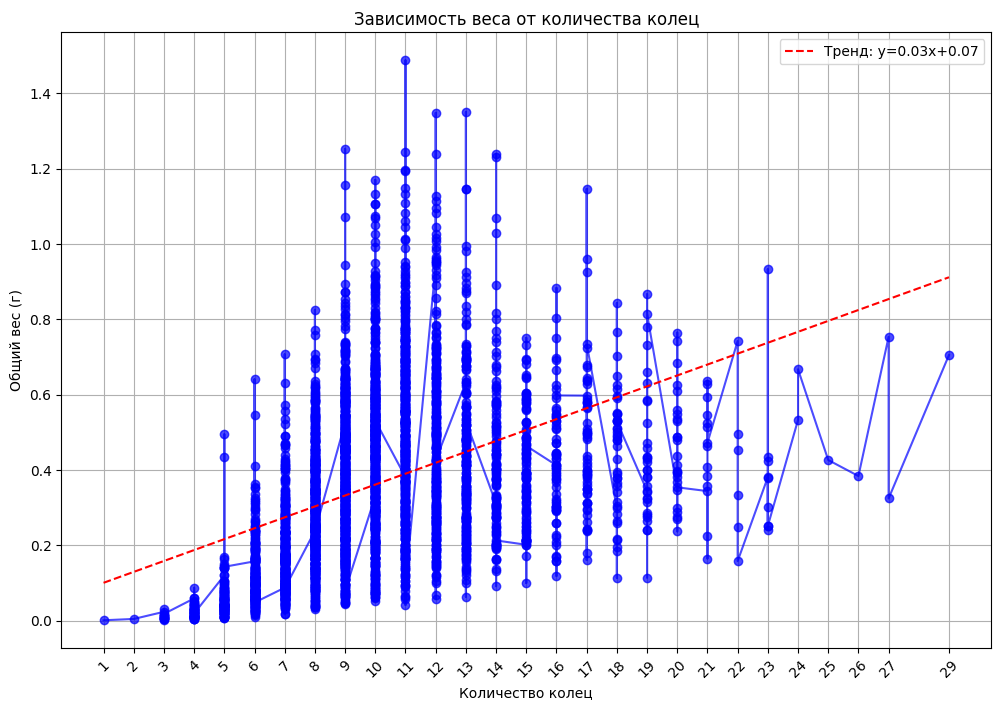

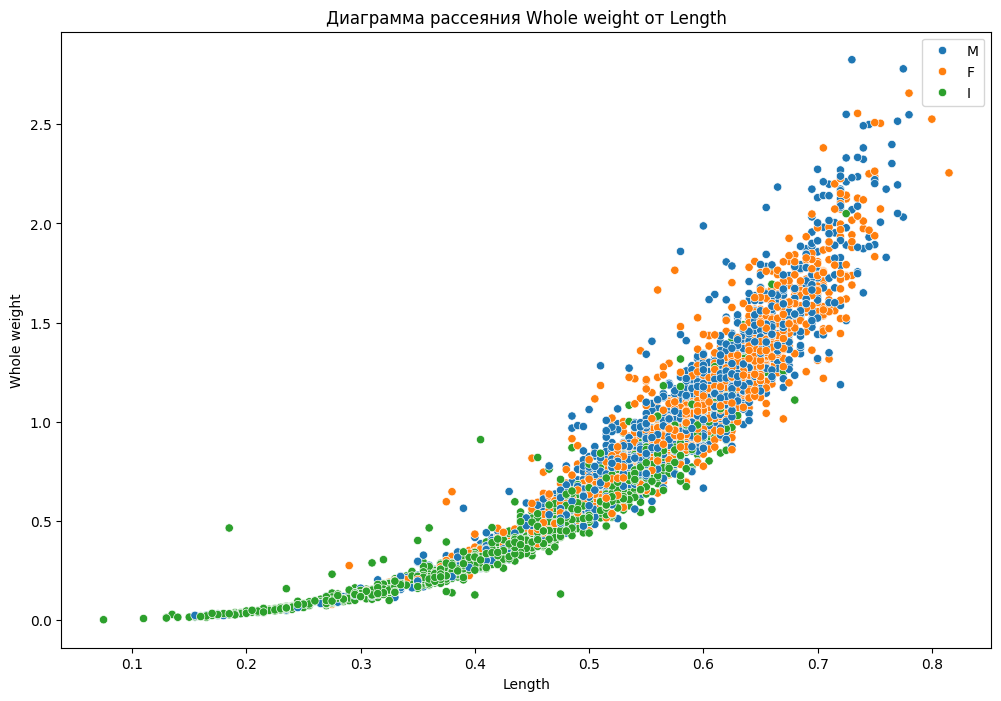

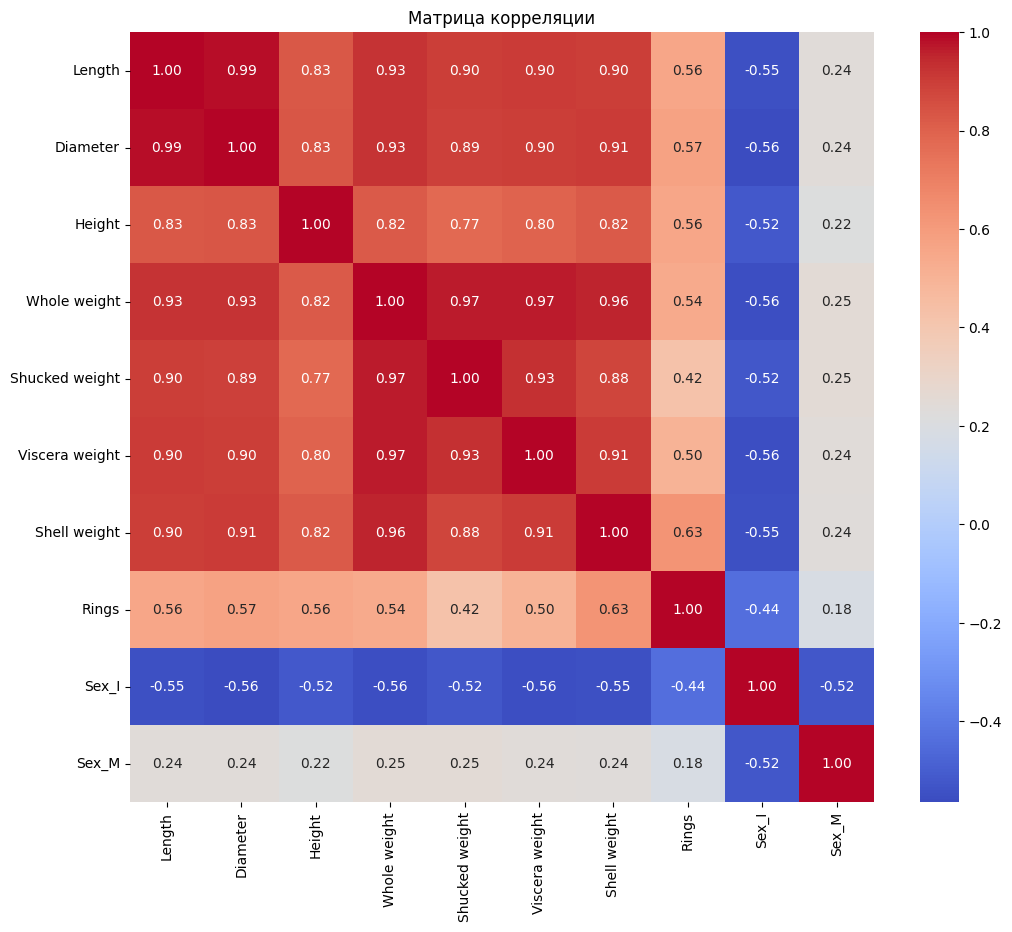

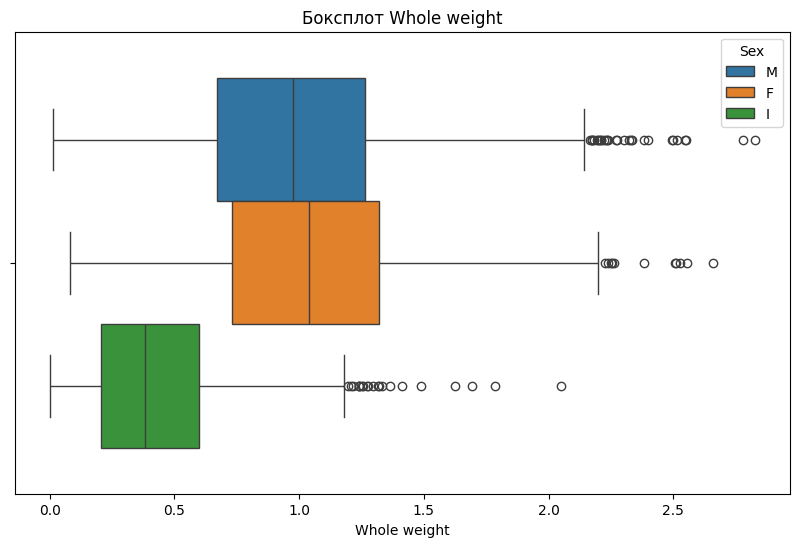

In [84]:
#main.ru
import ml_module as ml
import data_processing as proc
import data_loader as load
import missing_values
import visualization
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Загрузка данных
data = load_csv('abalone.csv')

# Проверка пропусков
missing_info = check_missing_values(data)
print("Общее количество пропусков:", missing_info['total_missing'])
print("Пропуски по столбцам:\n", missing_info['missing_by_column'])


# Получение сводной информации
summary = get_missing_summary(data)
print("\nСводная информация о пропусках:\n", summary)

# Извлекаем X и y из обработанных данных
X = processed_data['X']  # <-- Добавляем эту строку
y = processed_data['y']  # <-- Добавляем эту строку

# Параметры модели
target_column = 'Rings'
# Предобработка данных
processed_data = preprocess_data(data, target_column)

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Обучение модели
model = train_model(X_train, y_train)

# Предсказание
y_pred = predict(model, X_test)

# Оценка модели
mse, r2 = evaluate_model(y_test, y_pred)
print(f"Среднеквадратичная ошибка: {mse:.2f}")
print(f"Коэффициент детерминации R^2: {r2:.2f}")

# Визуализация истинных и предсказанных значений
def plot_predictions(y_true, y_pred, num_points=100):
    plt.figure(figsize=(10, 5))
    plt.scatter(range(num_points), y_true[:num_points], color='blue', label='Истинные значения')
    plt.scatter(range(num_points), y_pred[:num_points], color='red', label='Предсказанные значения')
    plt.xlabel('Индекс')
    plt.ylabel('Значение Rings')
    plt.title(f'Истинные и предсказанные значения Rings (первые {num_points} точек)')
    plt.legend()
    plt.show()

plot_predictions(y_test, y_pred)

if __name__ == "__main__":
    try:
        # Загрузка данных
        data = pd.read_csv('abalone.csv')

        # Создаем объект визуализатора
        visualizer = DataVisualizer(data)

        # Примеры визуализации
        visualizer.plot_histogram('Length')
        visualizer.plot_line_chart('Rings','Shucked weight')
        visualizer.plot_scatter('Length', 'Whole weight', hue='Sex')
        visualizer.plot_correlation_matrix()
        visualizer.plot_boxplot('Whole weight', hue='Sex')

    except FileNotFoundError:
        print("Файл не найден. Проверьте путь к файлу.")
    except Exception as e:
        print(f"Произошла ошибка: {e}")


